<a href="https://colab.research.google.com/github/MiguelPastorB/pastorbeltra/blob/main/Bernoulli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import random
import sys
import os

# Añadimos la carpeta 'src' al path de búsqueda de Python
sys.path.append(os.path.abspath('src'))

from src.algorithms.algorithm import Algorithm
from src.algorithms.epsilon_greedy import EpsilonGreedy, DecayingEpsilonGreedy
from src.algorithms.ucb1 import UCB1
from src.algorithms.softmax import Softmax
from src.arms.arm import Arm
from src.arms.armnormal import ArmNormal
from src.arms.bandit import Bandit
from src.arms.armbinomial import ArmBinomial
from src.plotting.plotting import plot_average_rewards, plot_optimal_selections, plot_regret

seed = 2024
np.random.seed(seed)
random.seed(seed)

In [2]:
def run_experiment(algorithms, n_arms, n_steps, n_runs, sigma):
    """
    Ejecuta el experimento para brazos con Distribución Normal N(mu, sigma^2).
    """
    # Matrices para almacenar resultados [cite: 314-315]
    all_rewards = np.zeros((len(algorithms), n_steps))
    optimal_counts = np.zeros((len(algorithms), n_steps))
    regret_accumulated = np.zeros((len(algorithms), n_steps))

    # Definimos las medias (mu) de cada brazo
    # Se recomienda un rango que permita distinguir claramente el brazo óptimo
    means = np.linspace(10, 50, n_arms) 
    optimal_arm_idx = np.argmax(means)
    max_mu = means[optimal_arm_idx]

    for run in range(n_runs):
        # Instanciamos los brazos con distribución Normal [cite: 399, 465]
        # Cada brazo tiene su propia media (mu) pero comparten la misma desviacion (sigma)
        arms = [ArmNormal(mu=m, sigma=sigma) for m in means]
        bandit = Bandit(arms)
        
        # Reiniciamos los algoritmos para asegurar independencia entre ejecuciones [cite: 469]
        for alg in algorithms:
            alg.reset() 

        for step in range(n_steps):
            for i, alg in enumerate(algorithms):
                # 1. Selección del brazo según la política del agente [cite: 372-373]
                arm_idx = alg.select_arm()
                
                # 2. Obtención de recompensa continua [cite: 374, 601]
                reward = bandit.pull_arm(arm_idx)
                
                # 3. Actualización de las estimaciones del agente [cite: 491]
                alg.update(arm_idx, reward)
                
                # Registro de métricas
                all_rewards[i, step] += reward
                if arm_idx == optimal_arm_idx:
                    optimal_counts[i, step] += 1
                
                # El regret se basa en la diferencia de las medias teoricas (mu* - mu_elegido) [cite: 379-381]
                current_regret = max_mu - means[arm_idx]
                regret_accumulated[i, step] += current_regret

    # Promediamos resultados para obtener curvas suaves 
    avg_rewards = all_rewards / n_runs
    avg_optimal = (optimal_counts / n_runs) * 100 
    avg_regret = np.cumsum(regret_accumulated / n_runs, axis=1) 

    return avg_rewards, avg_optimal, avg_regret

In [5]:
n_arms = 10
n_steps = 1000
n_runs = 2000 # Un número alto garantiza rigor metodológico
sigma_val_low = 1.0
sigma_val_high = 20.0

# Lista de algoritmos a comparar
all_algorithms = [
    EpsilonGreedy(k=n_arms, epsilon=0.1),
    DecayingEpsilonGreedy(k=n_arms), # Variante recomendada [cite: 459]
    UCB1(k=n_arms),
    Softmax(k=n_arms, temperature=5.0) # Subimos la temperatura por la escala de recompensas
]

# Ejecutamos
avg_rewards_low, opt_selections_low, regret_data_low = run_experiment(all_algorithms, n_arms, n_steps, n_runs, sigma=sigma_val_low)
avg_rewards_high, opt_selections_high, regret_data_high = run_experiment(all_algorithms, n_arms, n_steps, n_runs, sigma=sigma_val_high)

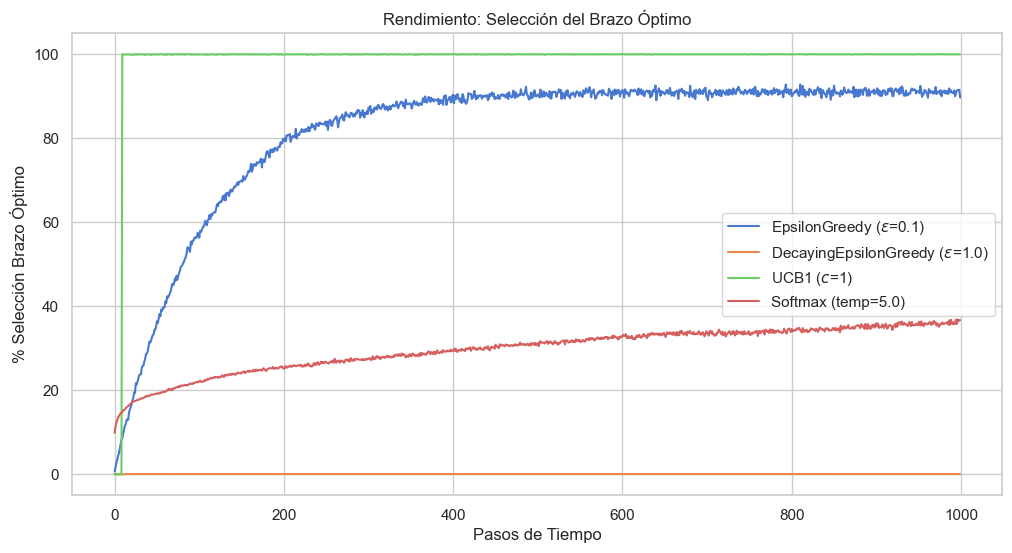

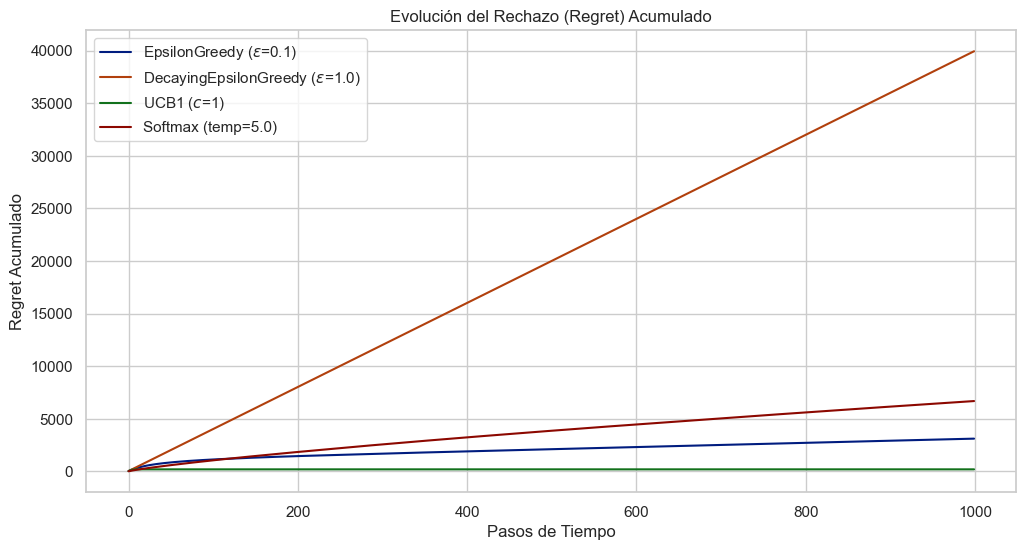

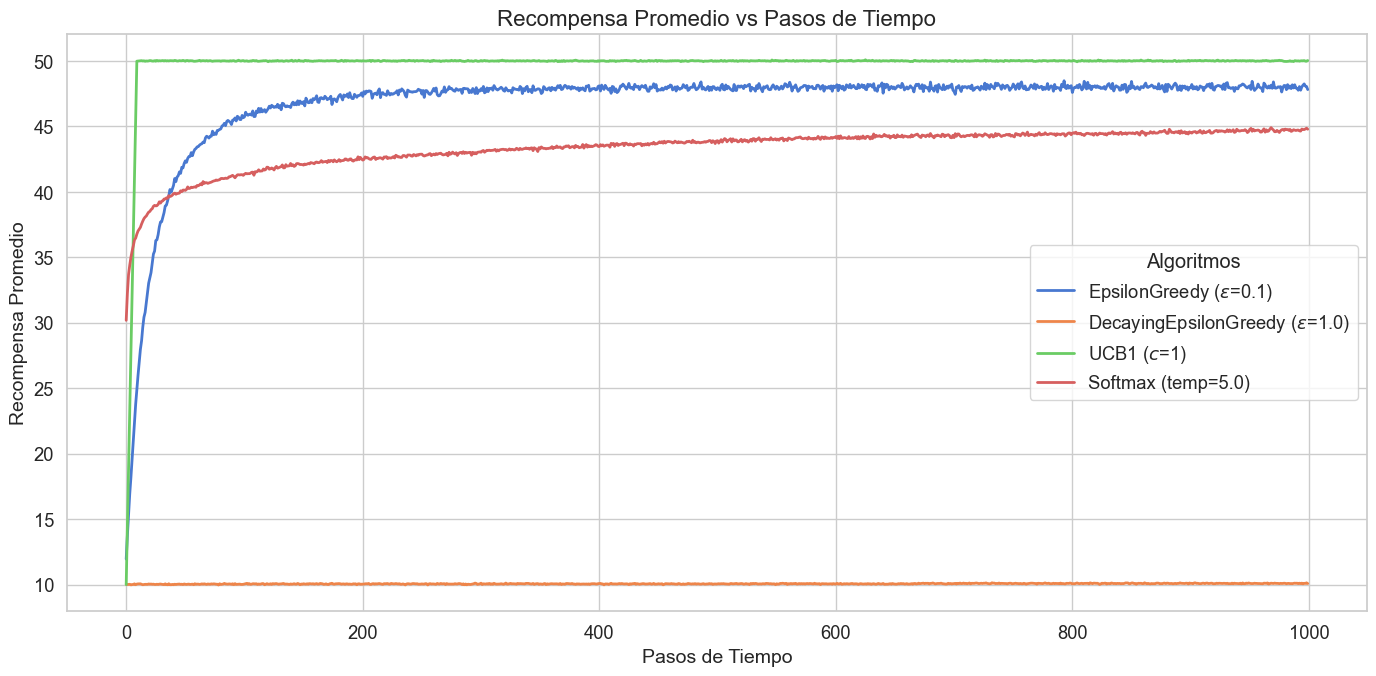

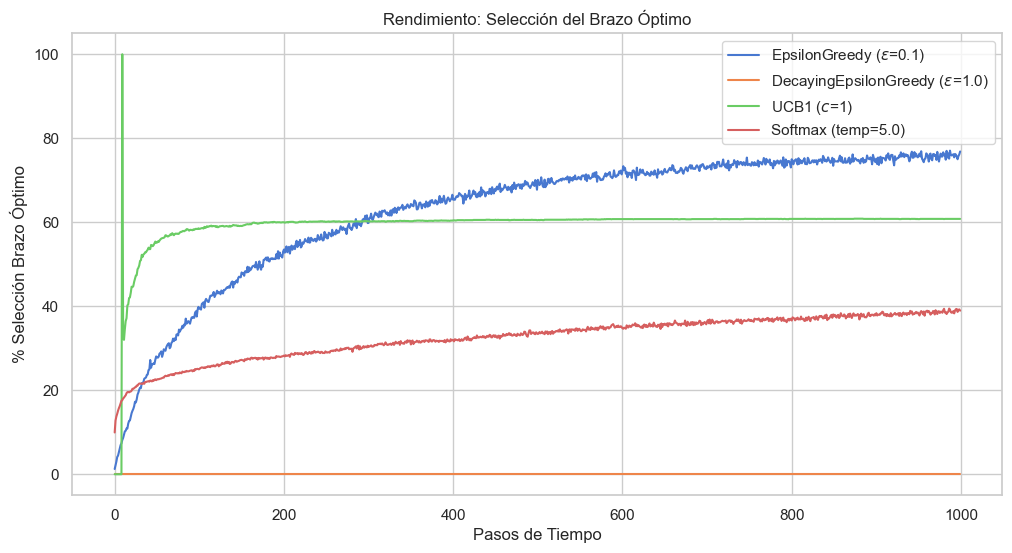

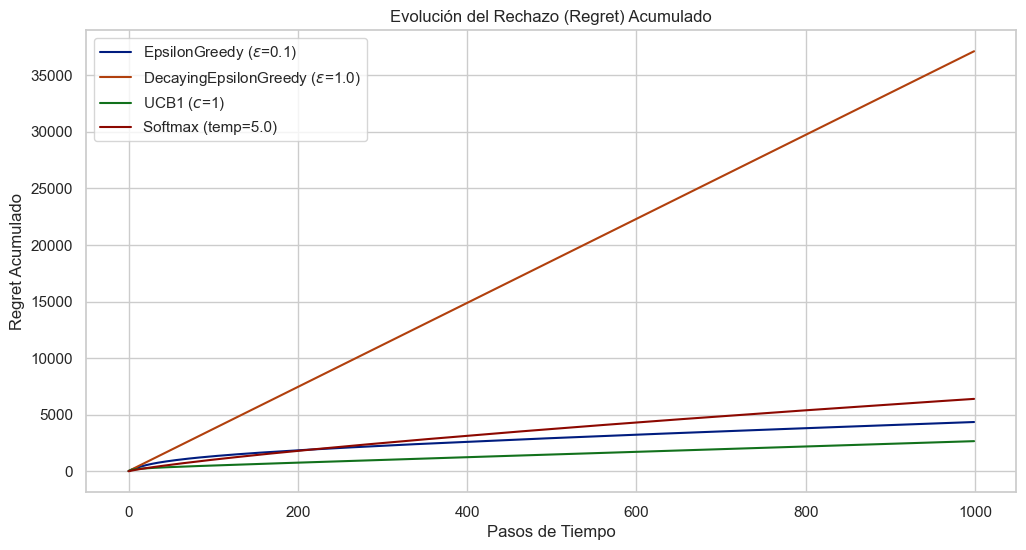

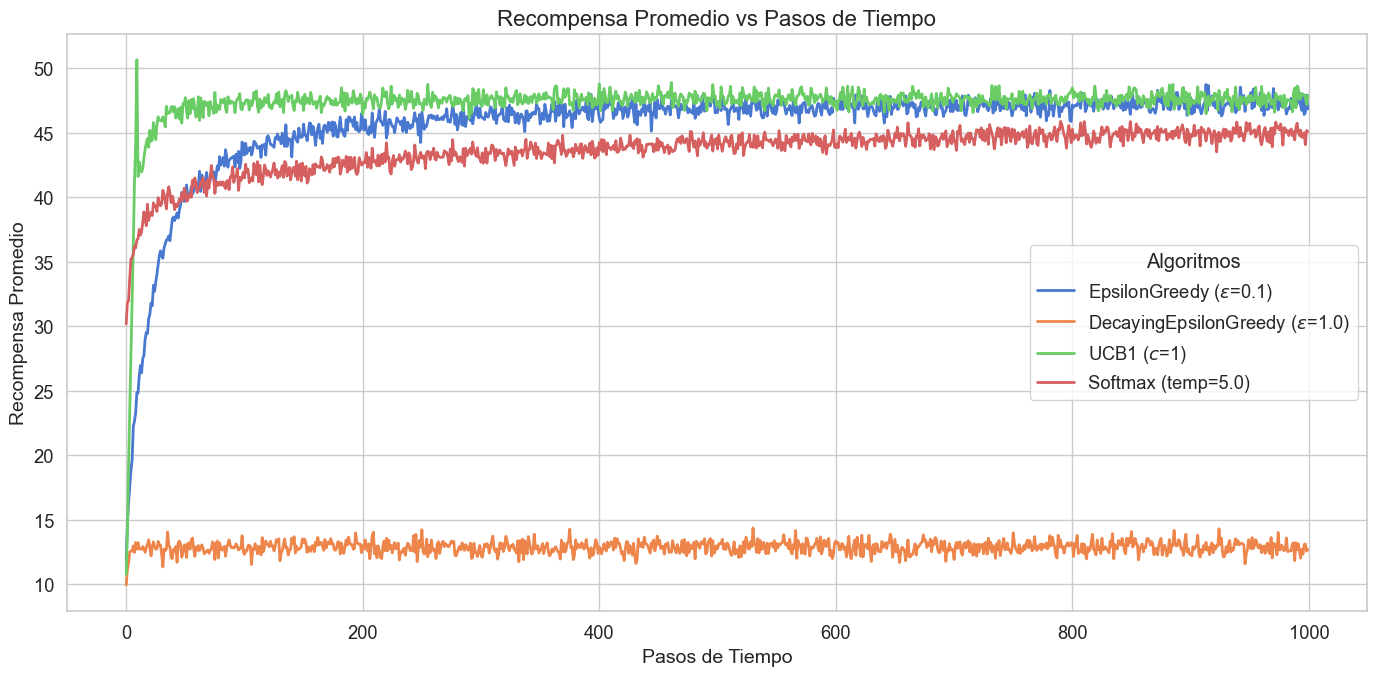

In [6]:
# Gráfica 1: % de Selección del Brazo Óptimo
plot_optimal_selections(n_steps, opt_selections_low, all_algorithms)

# Gráfica 2: Regret Acumulado
plot_regret(n_steps, regret_data_low, all_algorithms)

# Gráfica 3: Recompensa Promedio
plot_average_rewards(n_steps, avg_rewards_low, all_algorithms)

# Gráfica 1: % de Selección del Brazo Óptimo
plot_optimal_selections(n_steps, opt_selections_high, all_algorithms)

# Gráfica 2: Regret Acumulado
plot_regret(n_steps, regret_data_high, all_algorithms)

# Gráfica 3: Recompensa Promedio
plot_average_rewards(n_steps, avg_rewards_high, all_algorithms)